<a href="https://colab.research.google.com/github/zarasari/multi-domain-treatment-analysis/blob/main/Treatment_Attributes_ww.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Treatment Comparison Across Multiple Domains

This notebook explores simulated clinical trial data from the Wonderful Wednesday challenge.
It compares five treatments across five outcome domains over time using:

- mean domain score heatmaps
- change-from-baseline heatmaps
- preference-weighted summaries
- radar and benefit–risk plots


In [1]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120


In [2]:

URL = "https://raw.githubusercontent.com/VIS-SIG/Wonderful-Wednesdays/master/data/2026/2026-02-11/simulated_cdi_dataset.xlsx"

data = pd.read_excel(URL, engine="openpyxl")
data.head()


,USUBJID,TRTP,AVISIT,PARAMCD,AVAL
0,SUBJECT-001,Treatment D,Baseline,VS,85
1,SUBJECT-001,Treatment D,Baseline,PS,50
2,SUBJECT-001,Treatment D,Baseline,EW,33
3,SUBJECT-001,Treatment D,Baseline,SE,64
4,SUBJECT-001,Treatment D,Baseline,TA,80


## Setup

In [3]:

DOMAIN_ORDER = ["VS", "PS", "EW", "SE", "TA"]
DOMAIN_LABELS = {
    "VS": "Vital Signs",
    "PS": "Physical Symptoms",
    "EW": "Emotional Wellbeing",
    "SE": "Side Effects",
    "TA": "Treatment Admin",
}
TREATMENT_ORDER = [
    "Treatment A",
    "Treatment B",
    "Treatment C",
    "Treatment D",
    "Treatment E",
]
VISIT_ORDER = ["Baseline", "Month 6", "Month 12"]

baseline = data.query('AVISIT == "Baseline"').copy()
month6 = data.query('AVISIT == "Month 6"').copy()
month12 = data.query('AVISIT == "Month 12"').copy()
followup = data.query('AVISIT != "Baseline"').copy()


In [6]:

def summarise_scores(df, value_col="AVAL"):
    summary = (
        df.groupby(["TRTP", "PARAMCD"])[value_col]
        .mean()
        .reset_index()
        .pivot(index="TRTP", columns="PARAMCD", values=value_col)
        .reindex(index=TREATMENT_ORDER, columns=DOMAIN_ORDER)
        .rename(columns=DOMAIN_LABELS)
    )
    return summary


def plot_heatmap(summary, title, cmap="RdYlGn_r", vmin=None, vmax=None, center=None, filename=None):
    plt.figure(figsize=(10, 4.8))
    sns.heatmap(
        summary,
        annot=True,
        fmt=".1f",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        center=center,
        linewidths=0.5,
    )
    plt.title(title)
    plt.xlabel("")
    plt.ylabel("Treatment")
    plt.xticks(rotation=20, ha="right")
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


## Mean domain scores at follow-up visits

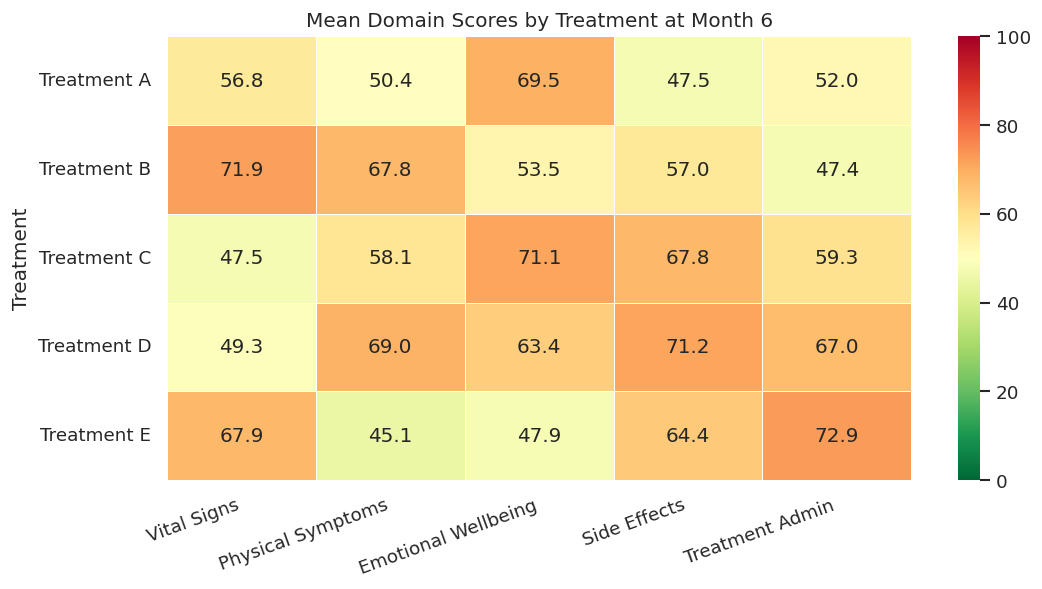

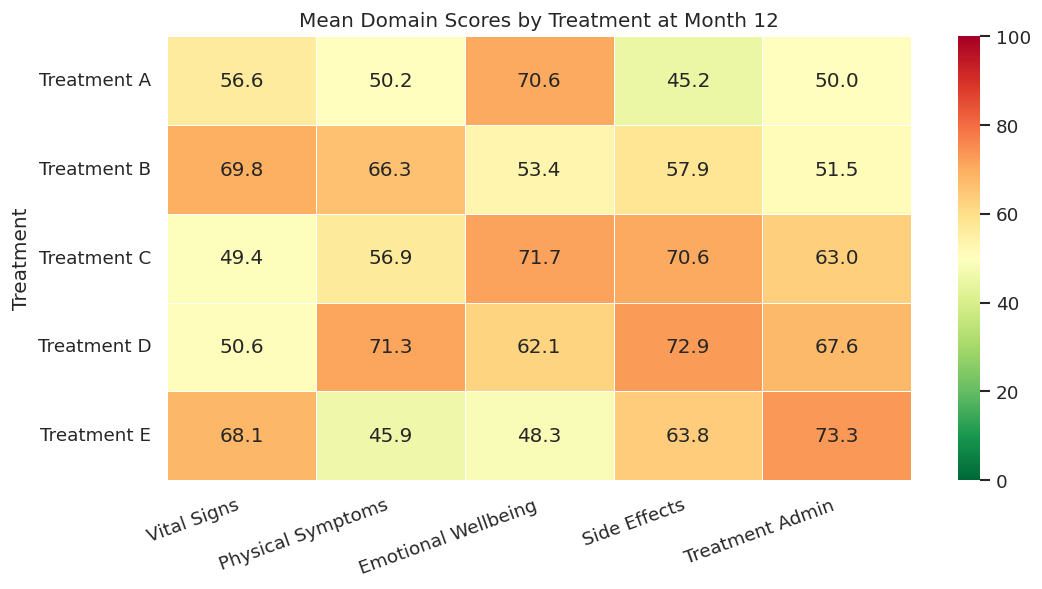

In [7]:

month6_summary = summarise_scores(month6)
month12_summary = summarise_scores(month12)

plot_heatmap(
    month6_summary,
    "Mean Domain Scores by Treatment at Month 6",
    cmap="RdYlGn_r",
    vmin=0,
    vmax=100,
    filename="month6_heatmap.png",
)

plot_heatmap(
    month12_summary,
    "Mean Domain Scores by Treatment at Month 12",
    cmap="RdYlGn_r",
    vmin=0,
    vmax=100,
    filename="month12_heatmap.png",
)


## Change from baseline

In [8]:

wide = (
    data.pivot_table(
        index=["USUBJID", "TRTP", "PARAMCD"],
        columns="AVISIT",
        values="AVAL",
    )
    .reset_index()
)

wide["chg_m6"] = wide["Month 6"] - wide["Baseline"]
wide["chg_m12"] = wide["Month 12"] - wide["Baseline"]
wide.head()


AVISIT,USUBJID,TRTP,PARAMCD,Baseline,Month 12,Month 6,chg_m6,chg_m12
0,SUBJECT-001,Treatment D,EW,33.0,53.0,72.0,39.0,20.0
1,SUBJECT-001,Treatment D,PS,50.0,83.0,60.0,10.0,33.0
2,SUBJECT-001,Treatment D,SE,64.0,100.0,94.0,30.0,36.0
3,SUBJECT-001,Treatment D,TA,80.0,100.0,92.0,12.0,20.0
4,SUBJECT-001,Treatment D,VS,85.0,88.0,80.0,-5.0,3.0


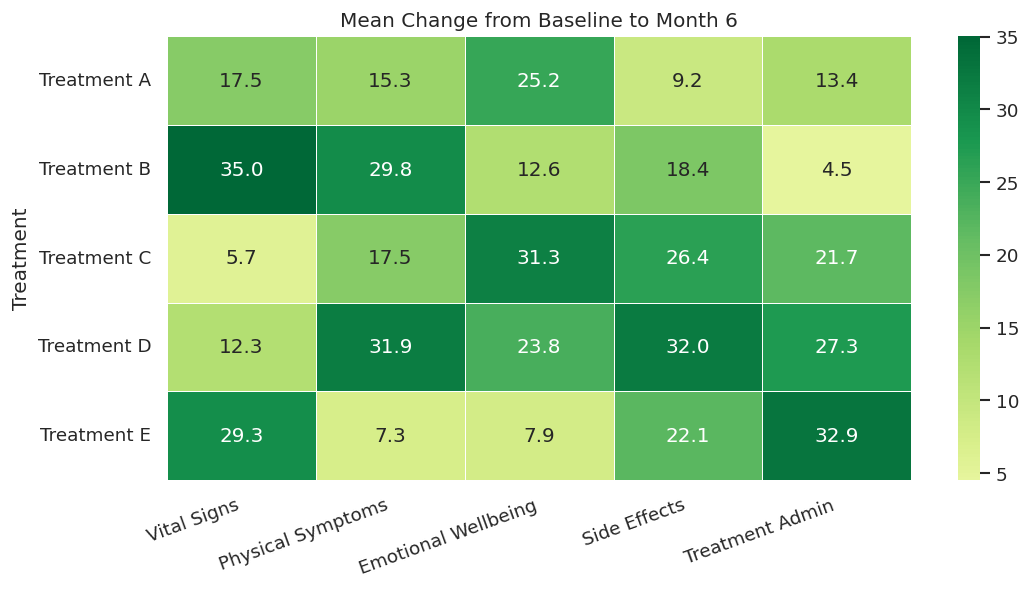

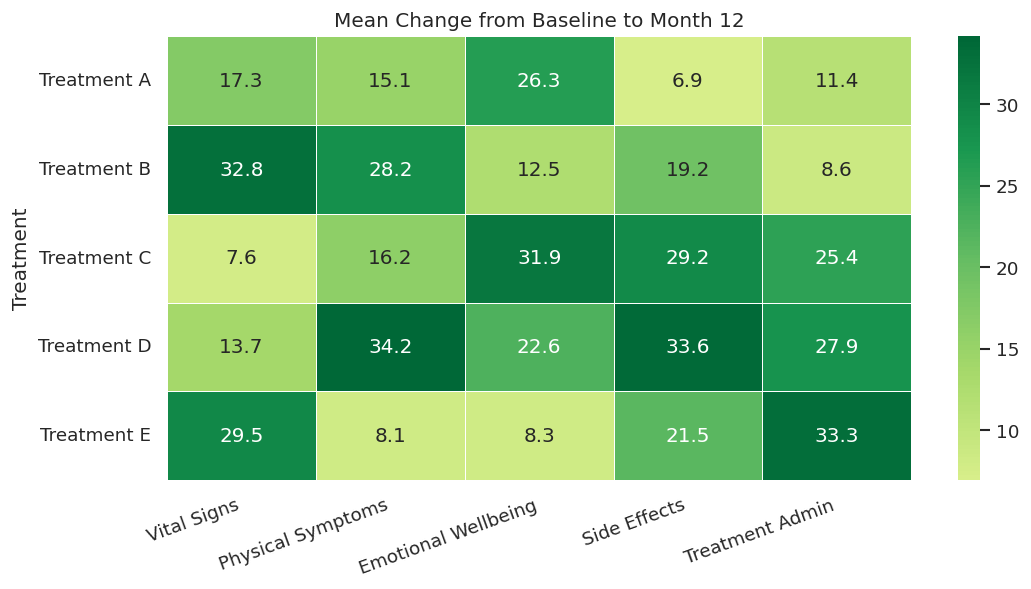

In [9]:

chg6_summary = summarise_scores(wide, value_col="chg_m6")
chg12_summary = summarise_scores(wide, value_col="chg_m12")

plot_heatmap(
    chg6_summary,
    "Mean Change from Baseline to Month 6",
    cmap="RdYlGn",
    center=0,
    filename="chg6_heatmap.png",
)

plot_heatmap(
    chg12_summary,
    "Mean Change from Baseline to Month 12",
    cmap="RdYlGn",
    center=0,
    filename="chg12_heatmap.png",
)


## Weighted preference profiles (Month 12)

In [10]:

preference_profiles = {
    "Equal": {
        "Vital Signs": 1,
        "Physical Symptoms": 1,
        "Emotional Wellbeing": 1,
        "Side Effects": 1,
        "Treatment Admin": 1,
    },
    "Symptoms focus": {
        "Vital Signs": 1,
        "Physical Symptoms": 4,
        "Emotional Wellbeing": 1,
        "Side Effects": 1,
        "Treatment Admin": 1,
    },
    "Emotional focus": {
        "Vital Signs": 1,
        "Physical Symptoms": 1,
        "Emotional Wellbeing": 4,
        "Side Effects": 1,
        "Treatment Admin": 1,
    },
    "Side effects": {
        "Vital Signs": 1,
        "Physical Symptoms": 1,
        "Emotional Wellbeing": 1,
        "Side Effects": 4,
        "Treatment Admin": 1,
    },
    "Convenience": {
        "Vital Signs": 1,
        "Physical Symptoms": 1,
        "Emotional Wellbeing": 1,
        "Side Effects": 1,
        "Treatment Admin": 4,
    },
}

weighted_results = {}
for profile_name, weights in preference_profiles.items():
    weight_series = pd.Series(weights)
    weighted_score = month12_summary.mul(weight_series, axis=1).sum(axis=1) / weight_series.sum()
    weighted_results[profile_name] = weighted_score

weighted_results_df = pd.DataFrame(weighted_results)
weighted_results_df


,Equal,Symptoms focus,Emotional focus,Side effects,Convenience
TRTP,,,,,
Treatment A,54.531959,52.894330,60.560567,51.050258,52.836340
Treatment B,59.752577,62.192010,57.359536,59.048969,56.659794
Treatment C,62.297959,60.257653,65.806122,65.423469,62.549745
Treatment D,64.902752,67.292431,63.869266,67.887615,65.912844
Treatment E,59.858586,54.623737,55.521465,61.324495,64.892677


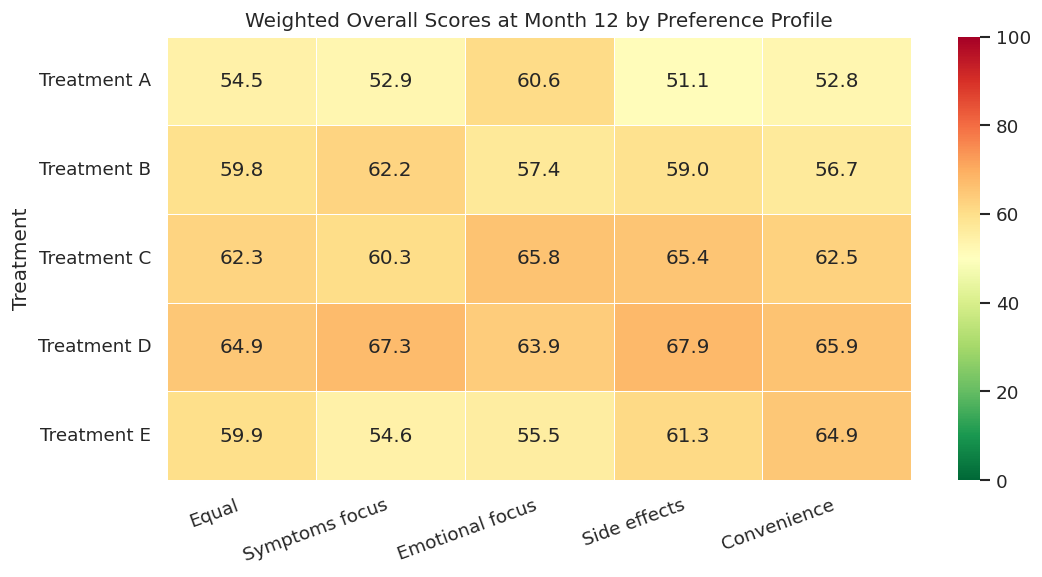

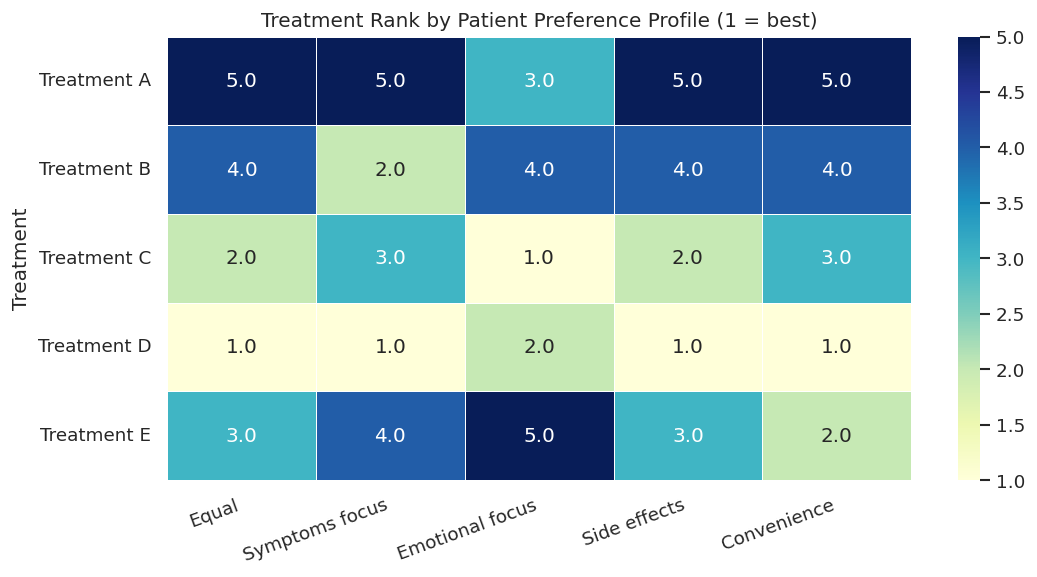

In [11]:

plot_heatmap(
    weighted_results_df,
    "Weighted Overall Scores at Month 12 by Preference Profile",
    cmap="RdYlGn_r",
    vmin=0,
    vmax=100,
    filename="weighted_preference.png",
)

rank_df = weighted_results_df.rank(method="min", ascending=False)
plot_heatmap(
    rank_df,
    "Treatment Rank by Patient Preference Profile (1 = best)",
    cmap="YlGnBu",
    vmin=1,
    vmax=5,
    filename="ranking_heatmap.png",
)


## Radar chart: treatment profiles at Month 12

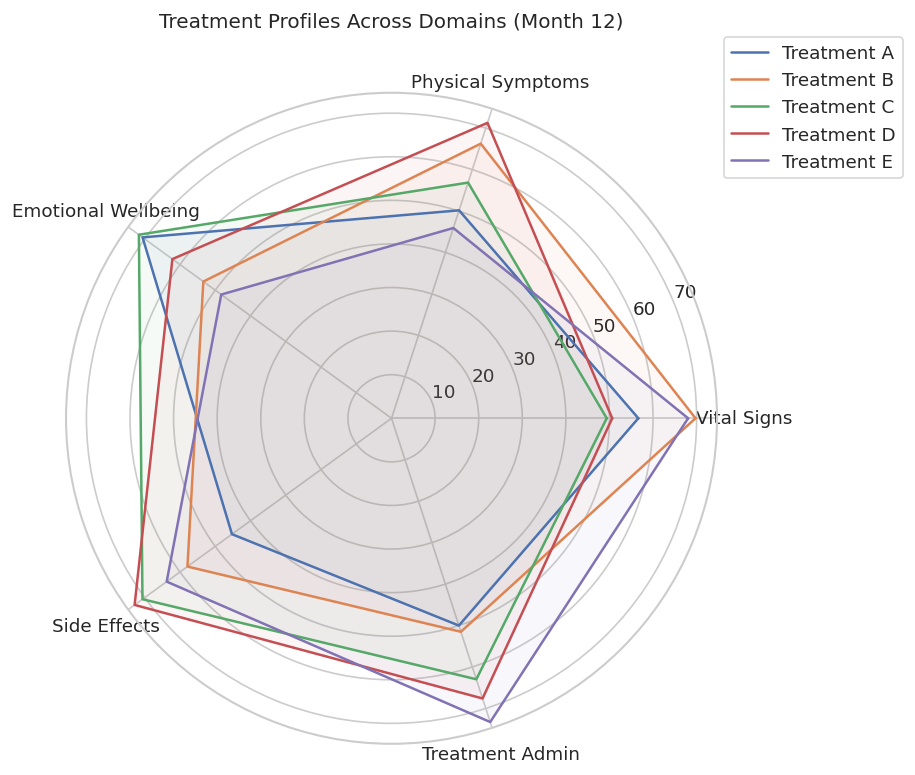

In [12]:

labels = month12_summary.columns.tolist()
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"polar": True})
for treatment in month12_summary.index:
    values = month12_summary.loc[treatment].tolist()
    values += values[:1]
    ax.plot(angles, values, label=treatment)
    ax.fill(angles, values, alpha=0.05)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_title("Treatment Profiles Across Domains (Month 12)", pad=40)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.subplots_adjust(top=0.9)
plt.savefig("treatment_across_domains.png", dpi=300, bbox_inches="tight")
plt.show()


## Benefit–risk trade-off plot

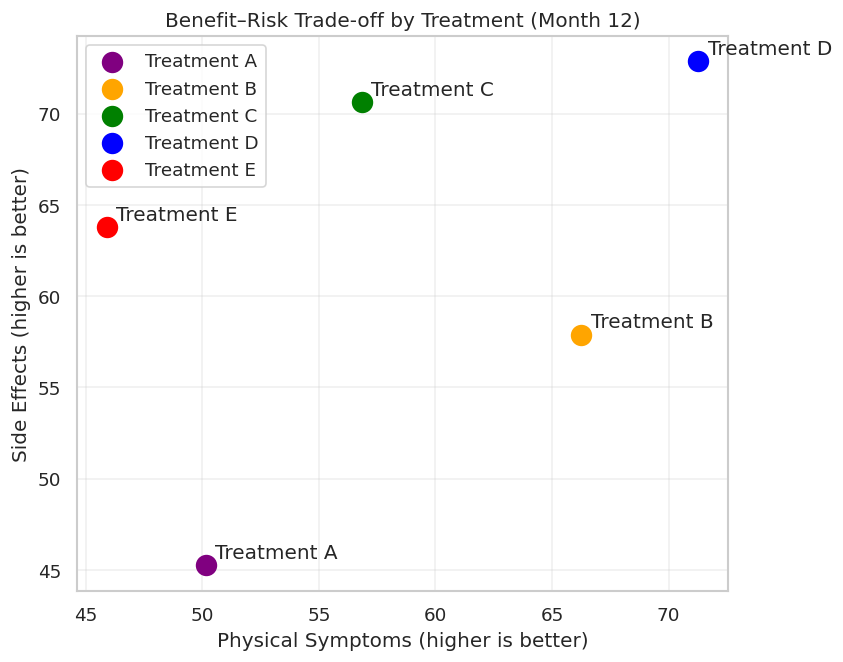

In [13]:

palette = {
    "Treatment A": "purple",
    "Treatment B": "orange",
    "Treatment C": "green",
    "Treatment D": "blue",
    "Treatment E": "red",
}

plt.figure(figsize=(7, 6))
for treatment in month12_summary.index:
    x = month12_summary.loc[treatment, "Physical Symptoms"]
    y = month12_summary.loc[treatment, "Side Effects"]
    plt.scatter(x, y, s=140, label=treatment, color=palette[treatment])
    plt.text(x + 0.4, y + 0.4, treatment)

plt.xlabel("Physical Symptoms (higher is better)")
plt.ylabel("Side Effects (higher is better)")
plt.title("Benefit–Risk Trade-off by Treatment (Month 12)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig("benefit_risk_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()


## Optional exploratory plots

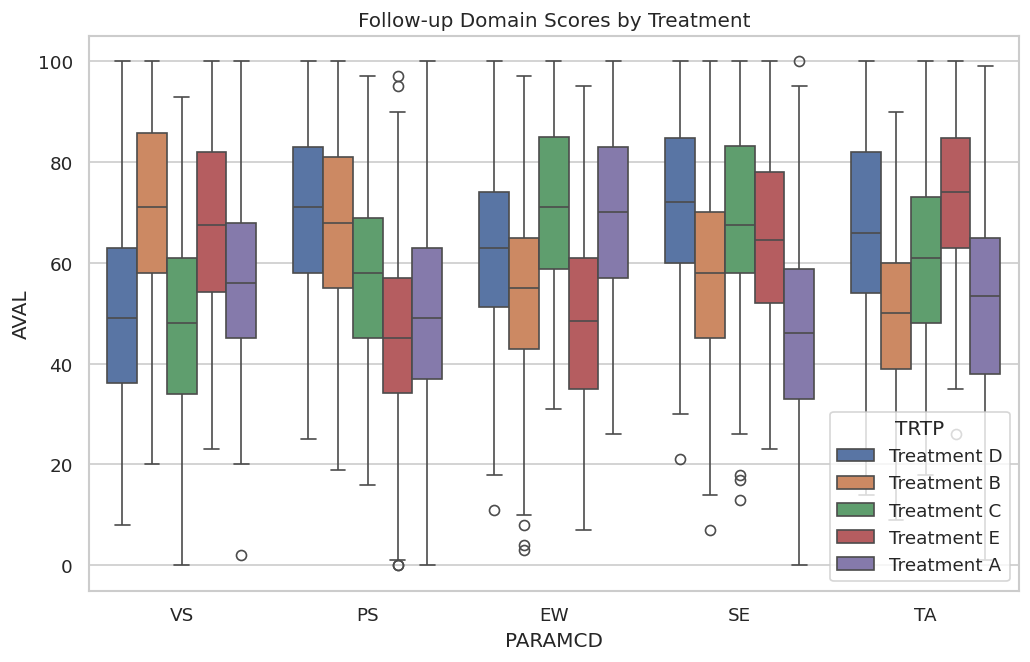

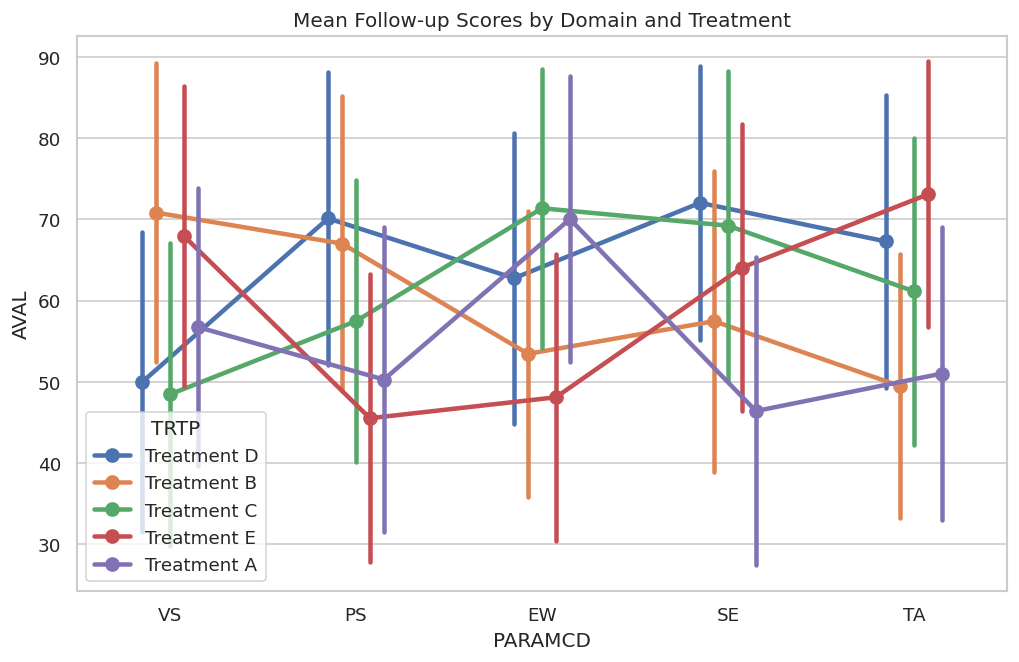

In [14]:

plt.figure(figsize=(10, 6))
sns.boxplot(data=followup, x="PARAMCD", y="AVAL", hue="TRTP")
plt.title("Follow-up Domain Scores by Treatment")
plt.show()

plt.figure(figsize=(10, 6))
sns.pointplot(data=followup, x="PARAMCD", y="AVAL", hue="TRTP", dodge=0.3, errorbar="sd")
plt.title("Mean Follow-up Scores by Domain and Treatment")
plt.show()
